<a href="https://colab.research.google.com/github/songseunghyeon0110/2026_bigdata_computing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  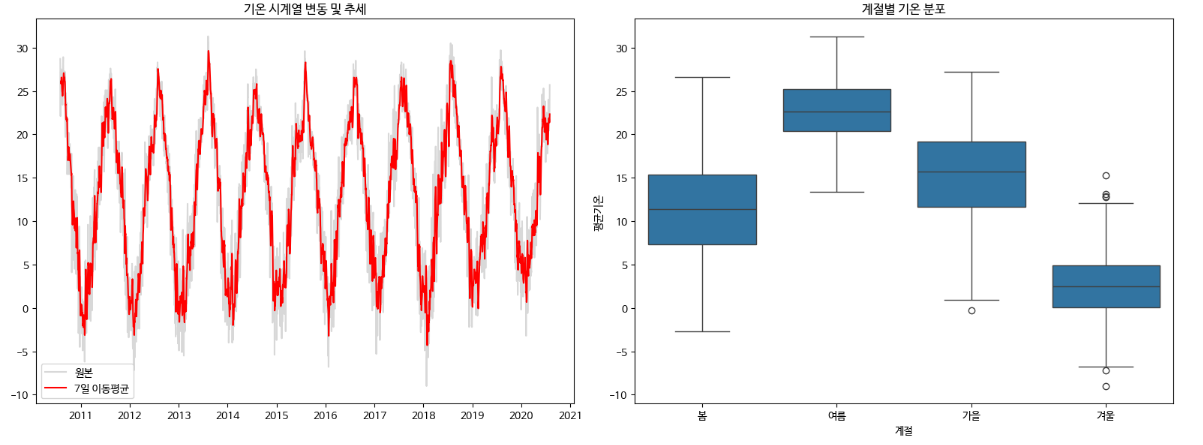

  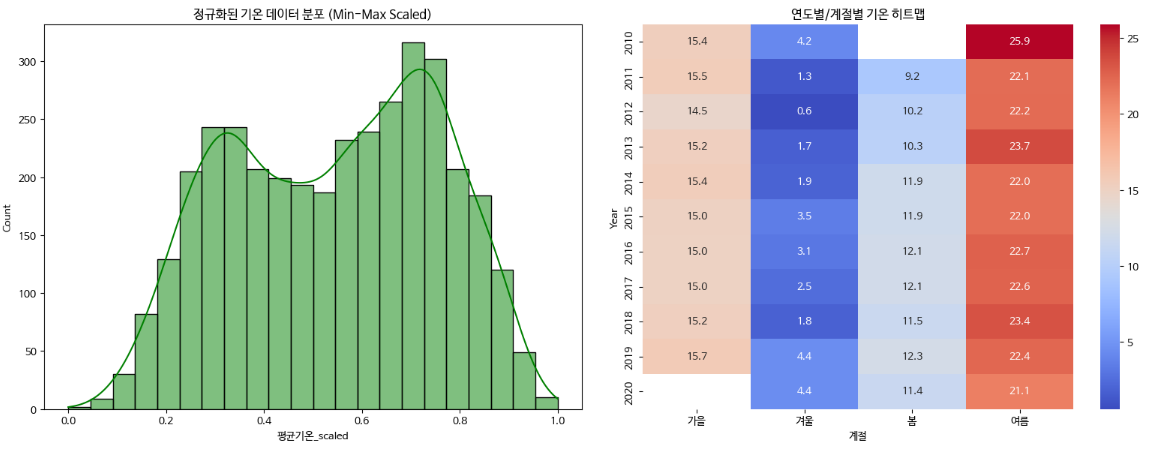



✅ 환경 설정 및 한글 폰트 로드 완료


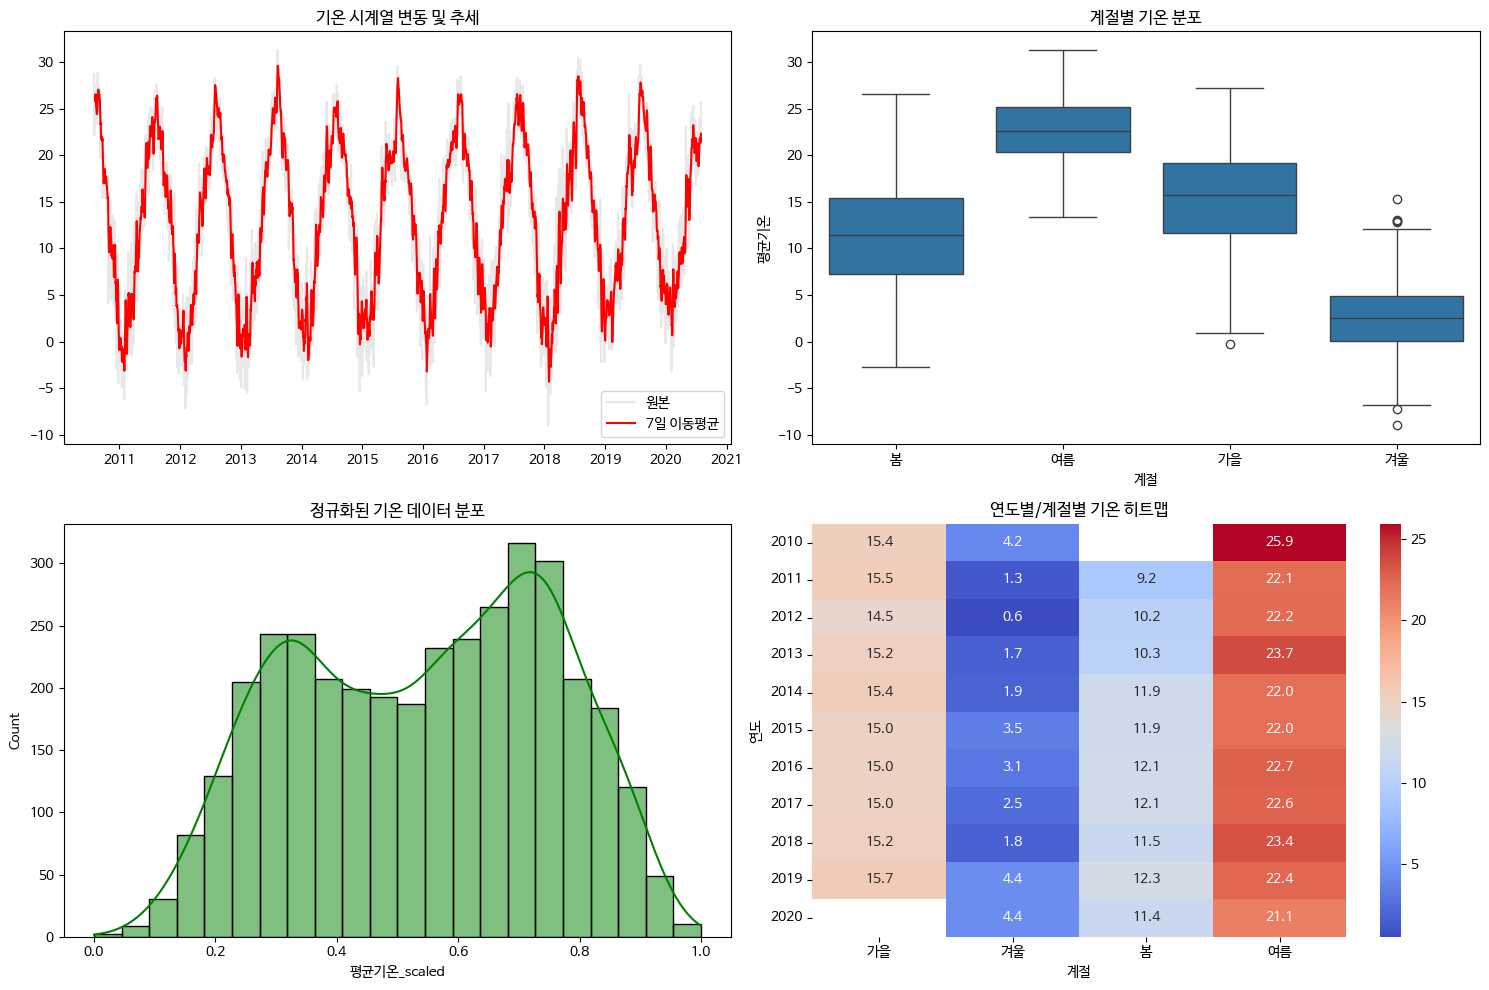

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings

def setup_environment():
  warnings.filterwarnings('ignore')

  # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
  font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
  if not os.path.exists(font_path):
    # Colab 등 리눅스 환경에서 폰트 설치
    os.system('sudo apt-get install -y fonts-nanum > /dev/null')

  # 2. 폰트 매니저에 등록
  if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
  else:
    # 윈도우 환경인 경우 'Malgun Gothic'
    plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

  plt.rcParams['axes.unicode_minus'] = False
  print("✅ 환경 설정 및 한글 폰트 로드 완료")

def preprocess_data(df):
  df = df.sort_index().interpolate()
  df['7일_이동평균'] = df['평균기온'].rolling(window=7).mean()

  df['연도'] = df.index.year

  season = []
  for month in df.index.month:
    if month in [3, 4, 5]:
      season.append('봄')
    elif month in [6, 7, 8]:
      season.append('여름')
    elif month in [9, 10, 11]:
      season.append('가을')
    else:
      season.append('겨울')

  df['계절'] = season

  return df

def normalize_data(df, col):
  col_min = df[col].min()
  col_max = df[col].max()
  df[f'{col}_scaled'] = (df[col] - col_min) / (col_max - col_min)
  return df

def analyze_data(df):
  season = df.groupby('계절')['평균기온'].describe()
  pivot_df = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')
  pivot_df = pivot_df[['가을', '겨울', '봄', '여름']]
  return season, pivot_df

def generate_visualizations(df, pivot_df):
  fig, axes = plt.subplots(2, 2, figsize=(15, 10))

  axes[0, 0].plot(df.index, df['평균기온'], color='lightgray', alpha=0.5, label='원본')
  axes[0, 0].plot(df.index, df['7일_이동평균'], color='red', label='7일 이동평균')
  axes[0, 0].set_title('기온 시계열 변동 및 추세')
  axes[0, 0].legend()

  sns.boxplot(x='계절', y='평균기온', data=df, order=['봄', '여름', '가을', '겨울'], ax=axes[0, 1])
  axes[0, 1].set_title('계절별 기온 분포')

  sns.histplot(df['평균기온_scaled'], kde=True, color='green', ax=axes[1, 0])
  axes[1, 0].set_title('정규화된 기온 데이터 분포')

  sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[1, 1])
  axes[1, 1].set_title('연도별/계절별 기온 히트맵')

  plt.tight_layout()
  plt.show()

def save_to_excel(df, season, pivot_df, filename):
  """엑셀 내보내기 함수 (요구 사항)"""
  with pd.ExcelWriter(filename) as writer:
    df.to_excel(writer, sheet_name='전처리 데이터')
    season.to_excel(writer, sheet_name='계절별 통계')
    pivot_df.to_excel(writer, sheet_name='연도별 피벗')

if __name__ == "__main__":
  setup_environment()

  url = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'
  result_file = 'weather_analysis_report.xlsx'

  weather_df = pd.read_csv(url, encoding='cp949')
  weather_df.set_index('일시', inplace=True)
  weather_df.index = pd.to_datetime(weather_df.index)

  weather_df = preprocess_data(weather_df)
  weather_df = normalize_data(weather_df, '평균기온')

  season, pivot = analyze_data(weather_df)

  generate_visualizations(weather_df, pivot)
  save_to_excel(weather_df, season, pivot, result_file)